# 04 — Exploratory Data Analysis

## Olist E-Commerce Business Analytics

### Objective

This notebook explores Olist’s historical marketplace performance and identifies patterns that require deeper business analysis.

The exploratory analysis covers:

- Overall business health
- Order completion and cancellation
- Product and payment values
- Monthly order and sales trends
- Product-category performance
- Payment behaviour
- Customer review scores
- Delivery performance
- Initial business hypotheses

This notebook describes observed historical patterns. It does not make causal claims or forecasts.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

plt.style.use("seaborn-v0_8-whitegrid")

COLORS = {
    "primary": "#173F5F",
    "secondary": "#20639B",
    "accent": "#F6C85F",
    "positive": "#3CAEA3",
    "negative": "#ED553B",
    "neutral": "#8A8A8A"
}

PROCESSED_DATA_DIR = Path("../data/processed").resolve()
IMAGE_OUTPUT_DIR = Path(
    "../images/notebook_outputs"
).resolve()

IMAGE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Processed data directory exists:", PROCESSED_DATA_DIR.exists())
print("Image output directory exists:", IMAGE_OUTPUT_DIR.exists())

Processed data directory exists: True
Image output directory exists: True


## 1. Load Analysis-Ready Data

The order-, customer-, and seller-level analytical tables are loaded alongside cleaned item and product reference tables. Explicit data types preserve ZIP-code prefixes and timestamps.

In [2]:
order_analytics = pd.read_csv(
    PROCESSED_DATA_DIR / "order_analytics.csv",
    dtype={
        "customer_zip_code_prefix": "string"
    },
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "maximum_shipping_limit",
        "latest_review_date",
        "latest_review_answer_timestamp"
    ]
)

customer_analytics = pd.read_csv(
    PROCESSED_DATA_DIR / "customer_analytics.csv",
    dtype={
        "latest_customer_zip_code_prefix": "string"
    },
    parse_dates=[
        "first_purchase_timestamp",
        "last_purchase_timestamp"
    ]
)

seller_analytics = pd.read_csv(
    PROCESSED_DATA_DIR / "seller_analytics.csv",
    dtype={
        "seller_zip_code_prefix": "string"
    },
    parse_dates=[
        "first_order_timestamp",
        "last_order_timestamp"
    ]
)

order_items = pd.read_csv(
    PROCESSED_DATA_DIR / "order_items_clean.csv",
    parse_dates=["shipping_limit_date"]
)

products = pd.read_csv(
    PROCESSED_DATA_DIR / "products_clean.csv"
)

category_translation = pd.read_csv(
    PROCESSED_DATA_DIR
    / "category_translation_clean.csv"
)

In [3]:
eda_dataset_summary = pd.DataFrame([
    {
        "dataset": "order_analytics",
        "rows": len(order_analytics),
        "columns": order_analytics.shape[1]
    },
    {
        "dataset": "customer_analytics",
        "rows": len(customer_analytics),
        "columns": customer_analytics.shape[1]
    },
    {
        "dataset": "seller_analytics",
        "rows": len(seller_analytics),
        "columns": seller_analytics.shape[1]
    },
    {
        "dataset": "order_items",
        "rows": len(order_items),
        "columns": order_items.shape[1]
    },
    {
        "dataset": "products",
        "rows": len(products),
        "columns": products.shape[1]
    },
    {
        "dataset": "category_translation",
        "rows": len(category_translation),
        "columns": category_translation.shape[1]
    }
])

eda_dataset_summary.style.format({
    "rows": "{:,.0f}",
    "columns": "{:,.0f}"
})

,dataset,rows,columns
0,order_analytics,"99,441",60
1,customer_analytics,"96,096",20
2,seller_analytics,"3,095",20
3,order_items,"112,650",7
4,products,"32,951",10
5,category_translation,74,2


***Observation:*** Six analysis-ready datasets were loaded successfully. The order table contains 99,441 records and will provide the primary marketplace KPIs, while item, product, customer, and seller tables will support more detailed analysis.

## 2. Overall Business Health

Overall order counts will use all recorded orders. Financial, satisfaction, and delivery KPIs will primarily use delivered orders because incomplete and cancelled transactions do not represent completed marketplace activity.

In [4]:
delivered_orders = order_analytics.loc[
    order_analytics["order_status"] == "delivered"
].copy()

valid_delivery_orders = delivered_orders.loc[
    delivered_orders["is_valid_for_delivery_analysis"]
].copy()

print("All recorded orders:", f"{len(order_analytics):,}")
print("Delivered orders:", f"{len(delivered_orders):,}")
print(
    "Valid delivery-analysis orders:",
    f"{len(valid_delivery_orders):,}"
)

All recorded orders: 99,441
Delivered orders: 96,478
Valid delivery-analysis orders: 96,281


In [5]:
analysis_start_date = (
    order_analytics["order_purchase_timestamp"].min()
)

analysis_end_date = (
    order_analytics["order_purchase_timestamp"].max()
)

business_health_kpis = pd.DataFrame([
    {
        "metric": "Recorded orders",
        "value": len(order_analytics),
        "definition": "All order records"
    },
    {
        "metric": "Delivered orders",
        "value": len(delivered_orders),
        "definition": "Orders with delivered status"
    },
    {
        "metric": "Order completion rate",
        "value": (
            len(delivered_orders)
            / len(order_analytics)
        ),
        "definition": "Delivered orders / recorded orders"
    },
    {
        "metric": "Unique customers",
        "value": order_analytics[
            "customer_unique_id"
        ].nunique(),
        "definition": "Distinct customer_unique_id"
    },
    {
        "metric": "Active sellers",
        "value": seller_analytics[
            "seller_id"
        ].nunique(),
        "definition": "Sellers represented in order items"
    },
    {
        "metric": "Delivered product value",
        "value": delivered_orders[
            "product_value"
        ].sum(),
        "definition": "Item price associated with delivered orders"
    },
    {
        "metric": "Delivered payment value",
        "value": delivered_orders[
            "total_payment_value"
        ].sum(),
        "definition": "Recorded payment value for delivered orders"
    },
    {
        "metric": "Average delivered-order payment",
        "value": delivered_orders[
            "total_payment_value"
        ].mean(),
        "definition": "Mean payment value per delivered order"
    },
    {
        "metric": "Average delivered-order review",
        "value": delivered_orders[
            "latest_review_score"
        ].mean(),
        "definition": "Mean latest review score for reviewed delivered orders"
    },
    {
        "metric": "On-time delivery rate",
        "value": (
            valid_delivery_orders[
                "is_on_time_delivery"
            ].mean()
        ),
        "definition": "On-time orders / valid delivery-analysis orders"
    }
])

business_health_kpis

,metric,value,definition
0,Recorded orders,"99,441.00",All order records
1,Delivered orders,"96,478.00",Orders with delivered status
2,Order completion rate,0.97,Delivered orders / recorded orders
3,Unique customers,"96,096.00",Distinct customer_unique_id
4,Active sellers,"3,095.00",Sellers represented in order items
5,Delivered product value,"13,221,498.11",Item price associated with delivered orders
6,Delivered payment value,"15,422,461.77",Recorded payment value for delivered orders
7,Average delivered-order payment,159.86,Mean payment value per delivered order
8,Average delivered-order review,4.16,Mean latest review score for reviewed delivere...
9,On-time delivery rate,0.93,On-time orders / valid delivery-analysis orders


In [6]:
print(
    "Analysis period:",
    analysis_start_date.strftime("%Y-%m-%d"),
    "to",
    analysis_end_date.strftime("%Y-%m-%d")
)

Analysis period: 2016-09-04 to 2018-10-17


***Observation:*** Between September 2016 and October 2018, Olist recorded 99,441 orders, of which 96,478 were delivered, producing a 97.02% completion rate. Delivered orders represented R$13.22 million in product value and R$15.42 million in recorded customer payments, with an average payment of R$159.86.

***Customer experience:*** Reviewed delivered orders received an average latest score of 4.16 out of 5, while 93.22% of orders eligible for delivery analysis arrived on or before their estimated calendar date.

***Time-period limitation:*** September 2016 and October 2018 are partial boundary months. They should not be compared directly with complete months when analysing monthly trends.

## 3. Order Status Distribution

Order statuses show how many transactions reached delivery and how many remained incomplete, were cancelled, or became unavailable.

In [7]:
order_status_summary = (
    order_analytics["order_status"]
    .value_counts()
    .rename_axis("order_status")
    .reset_index(name="order_count")
)

order_status_summary["order_rate"] = (
    order_status_summary["order_count"]
    / order_status_summary["order_count"].sum()
)

order_status_summary.style.format({
    "order_count": "{:,.0f}",
    "order_rate": "{:.2%}"
})

,order_status,order_count,order_rate
0,delivered,"96,478",97.02%
1,shipped,"1,107",1.11%
2,canceled,625,0.63%
3,unavailable,609,0.61%
4,invoiced,314,0.32%
5,processing,301,0.30%
6,created,5,0.01%
7,approved,2,0.00%


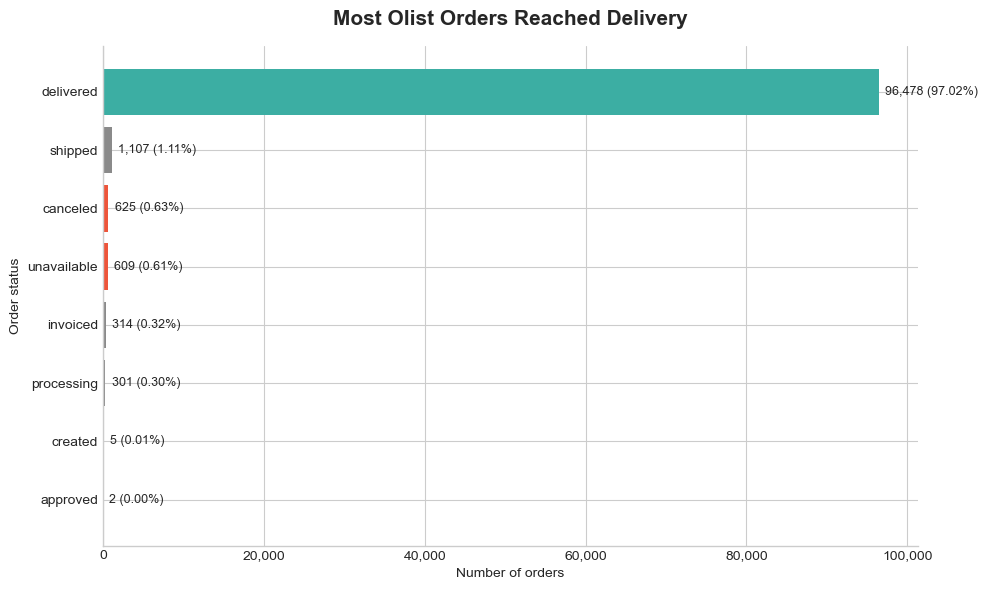

In [8]:
status_colors = [
    COLORS["positive"]
    if status == "delivered"
    else COLORS["negative"]
    if status in ["canceled", "unavailable"]
    else COLORS["neutral"]
    for status in order_status_summary["order_status"]
]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    order_status_summary["order_status"],
    order_status_summary["order_count"],
    color=status_colors
)

ax.invert_yaxis()

ax.set_title(
    "Most Olist Orders Reached Delivery",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Number of orders")
ax.set_ylabel("Order status")

ax.xaxis.set_major_formatter(
    mtick.StrMethodFormatter("{x:,.0f}")
)

for bar, count, rate in zip(
    bars,
    order_status_summary["order_count"],
    order_status_summary["order_rate"]
):
    ax.text(
        bar.get_width() + 800,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,.0f} ({rate:.2%})",
        va="center",
        fontsize=9
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    IMAGE_OUTPUT_DIR / "order_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** Delivered orders account for 97.02% of all recorded transactions. Cancelled and unavailable orders each represent less than 1%, while the remaining incomplete statuses collectively form a small share of marketplace activity.

***Business question:*** Although incomplete orders are uncommon overall, their product value, timing, and category concentration should be examined before concluding that they are operationally insignificant.

## 4. Monthly Order and Payment Trends

Monthly trends are calculated using the order purchase date. The comparison chart focuses on January 2017 through August 2018 to avoid misleading comparisons with incomplete boundary months.

In [9]:
delivered_orders["purchase_month_start"] = (
    delivered_orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_performance = (
    delivered_orders
    .groupby("purchase_month_start", as_index=False)
    .agg(
        delivered_orders=("order_id", "nunique"),
        delivered_product_value=("product_value", "sum"),
        delivered_payment_value=("total_payment_value", "sum")
    )
)

monthly_performance["average_order_payment"] = (
    monthly_performance["delivered_payment_value"]
    / monthly_performance["delivered_orders"]
)

monthly_performance["comparable_full_month"] = (
    monthly_performance["purchase_month_start"]
    .between("2017-01-01", "2018-08-01")
)

monthly_performance.style.format({
    "delivered_orders": "{:,.0f}",
    "delivered_product_value": "R$ {:,.2f}",
    "delivered_payment_value": "R$ {:,.2f}",
    "average_order_payment": "R$ {:,.2f}"
})

,purchase_month_start,delivered_orders,delivered_product_value,delivered_payment_value,average_order_payment,comparable_full_month
0,2016-09-01 00:00:00,1,R$ 134.97,R$ 0.00,R$ 0.00,False
1,2016-10-01 00:00:00,265,"R$ 40,325.11","R$ 46,566.71",R$ 175.72,False
2,2016-12-01 00:00:00,1,R$ 10.90,R$ 19.62,R$ 19.62,False
3,2017-01-01 00:00:00,750,"R$ 111,798.36","R$ 127,545.67",R$ 170.06,True
4,2017-02-01 00:00:00,"1,653","R$ 234,223.40","R$ 271,298.65",R$ 164.13,True
5,2017-03-01 00:00:00,"2,546","R$ 359,198.85","R$ 414,369.39",R$ 162.75,True
6,2017-04-01 00:00:00,"2,303","R$ 340,669.68","R$ 390,952.18",R$ 169.76,True
7,2017-05-01 00:00:00,"3,546","R$ 489,338.25","R$ 567,066.73",R$ 159.92,True
8,2017-06-01 00:00:00,"3,135","R$ 421,923.37","R$ 490,225.60",R$ 156.37,True
9,2017-07-01 00:00:00,"3,872","R$ 481,604.52","R$ 566,403.93",R$ 146.28,True


In [10]:
monthly_comparison = monthly_performance.loc[
    monthly_performance["comparable_full_month"]
].copy()

print(
    "Comparable period:",
    monthly_comparison["purchase_month_start"].min().strftime("%Y-%m"),
    "to",
    monthly_comparison["purchase_month_start"].max().strftime("%Y-%m")
)

print(
    "Months included:",
    len(monthly_comparison)
)

Comparable period: 2017-01 to 2018-08
Months included: 20


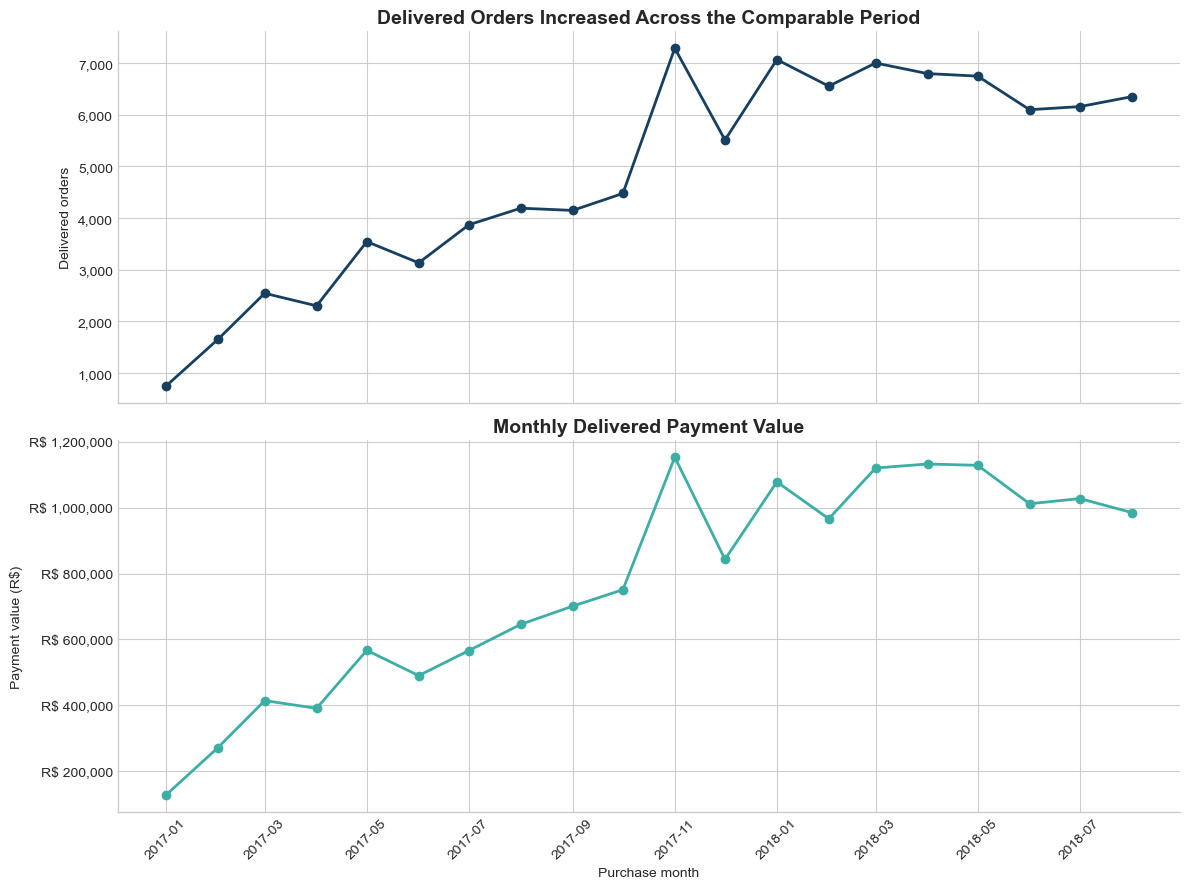

In [11]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 9),
    sharex=True
)

axes[0].plot(
    monthly_comparison["purchase_month_start"],
    monthly_comparison["delivered_orders"],
    color=COLORS["primary"],
    marker="o",
    linewidth=2
)

axes[0].set_title(
    "Delivered Orders Increased Across the Comparable Period",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_ylabel("Delivered orders")
axes[0].yaxis.set_major_formatter(
    mtick.StrMethodFormatter("{x:,.0f}")
)

axes[1].plot(
    monthly_comparison["purchase_month_start"],
    monthly_comparison["delivered_payment_value"],
    color=COLORS["positive"],
    marker="o",
    linewidth=2
)

axes[1].set_title(
    "Monthly Delivered Payment Value",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_ylabel("Payment value (R$)")
axes[1].set_xlabel("Purchase month")

axes[1].yaxis.set_major_formatter(
    mtick.StrMethodFormatter("R$ {x:,.0f}")
)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    IMAGE_OUTPUT_DIR / "monthly_order_payment_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** Delivered orders increased from 750 in January 2017 to 6,351 in August 2018, while monthly delivered payment value increased from approximately R$127,546 to R$985,414. Growth was strongest during 2017, with order volume peaking at 7,289 in November 2017.

***Interpretation:*** Average order payment remained within a relatively narrow range of approximately R$146–R$170 during the comparable period, suggesting that the increase in payment value was driven mainly by higher order volume rather than a sustained increase in spending per order.

***Business hypothesis:*** The November 2017 peak may reflect seasonal marketplace activity such as Black Friday, but the dataset alone does not establish its cause. Monthly volume appears more stable during 2018, generally remaining between approximately 6,100 and 7,100 delivered orders.

***Time-period limitation:*** Sparse months before January 2017 and records after August 2018 were excluded from the comparison chart to avoid presenting incomplete boundary periods as normal monthly performance.

## 5. Product-Category Performance

Order items are enriched with product categories and order status. Category performance will use item-level product value from delivered orders rather than customer payment value.

In [12]:
item_analysis = (
    order_items
    .merge(
        products[
            [
                "product_id",
                "product_category_name"
            ]
        ],
        on="product_id",
        how="left",
        validate="many_to_one"
    )
    .merge(
        category_translation,
        on="product_category_name",
        how="left",
        validate="many_to_one"
    )
    .merge(
        order_analytics[
            [
                "order_id",
                "order_status",
                "order_purchase_timestamp",
                "customer_state"
            ]
        ],
        on="order_id",
        how="left",
        validate="many_to_one"
    )
)

item_analysis_validation = pd.DataFrame([
    {
        "validation_check": "Item rows retained",
        "result": len(item_analysis),
        "expected": len(order_items)
    },
    {
        "validation_check": "Missing English categories",
        "result": item_analysis[
            "product_category_name_english"
        ].isna().sum(),
        "expected": 0
    },
    {
        "validation_check": "Product value retained",
        "result": round(item_analysis["price"].sum(), 2),
        "expected": round(order_items["price"].sum(), 2)
    }
])

item_analysis_validation["status"] = np.where(
    np.isclose(
        item_analysis_validation["result"],
        item_analysis_validation["expected"],
        atol=0.01
    ),
    "Passed",
    "Failed"
)

item_analysis_validation

,validation_check,result,expected,status
0,Item rows retained,"112,650.00","112,650.00",Passed
1,Missing English categories,0.00,0.00,Passed
2,Product value retained,"13,591,643.70","13,591,643.70",Passed


In [13]:
delivered_items = item_analysis.loc[
    item_analysis["order_status"] == "delivered"
].copy()

category_performance = (
    delivered_items
    .groupby(
        "product_category_name_english",
        as_index=False
    )
    .agg(
        delivered_orders=("order_id", "nunique"),
        items_sold=("order_item_id", "count"),
        product_value=("price", "sum"),
        freight_value=("freight_value", "sum"),
        average_item_price=("price", "mean")
    )
    .sort_values(
        "product_value",
        ascending=False
    )
    .reset_index(drop=True)
)

category_performance["product_value_share"] = (
    category_performance["product_value"]
    / category_performance["product_value"].sum()
)

top_categories = category_performance.head(10).copy()

top_categories.style.format({
    "delivered_orders": "{:,.0f}",
    "items_sold": "{:,.0f}",
    "product_value": "R$ {:,.2f}",
    "freight_value": "R$ {:,.2f}",
    "average_item_price": "R$ {:,.2f}",
    "product_value_share": "{:.2%}"
})

,product_category_name_english,delivered_orders,items_sold,product_value,freight_value,average_item_price,product_value_share
0,health_beauty,"8,647","9,465","R$ 1,233,131.72","R$ 178,957.81",R$ 130.28,9.33%
1,watches_gifts,"5,495","5,859","R$ 1,166,176.98","R$ 98,156.14",R$ 199.04,8.82%
2,bed_bath_table,"9,272","10,953","R$ 1,023,434.76","R$ 201,774.50",R$ 93.44,7.74%
3,sports_leisure,"7,530","8,431","R$ 954,852.55","R$ 163,404.36",R$ 113.25,7.22%
4,computers_accessories,"6,530","7,644","R$ 888,724.61","R$ 143,999.16",R$ 116.26,6.72%
5,furniture_decor,"6,307","8,160","R$ 711,927.69","R$ 168,402.23",R$ 87.25,5.38%
6,housewares,"5,743","6,795","R$ 615,628.69","R$ 142,763.56",R$ 90.60,4.66%
7,cool_stuff,"3,559","3,718","R$ 610,204.10","R$ 81,476.79",R$ 164.12,4.62%
8,auto,"3,810","4,140","R$ 578,966.65","R$ 90,488.10",R$ 139.85,4.38%
9,toys,"3,804","4,030","R$ 471,286.48","R$ 75,774.58",R$ 116.94,3.56%


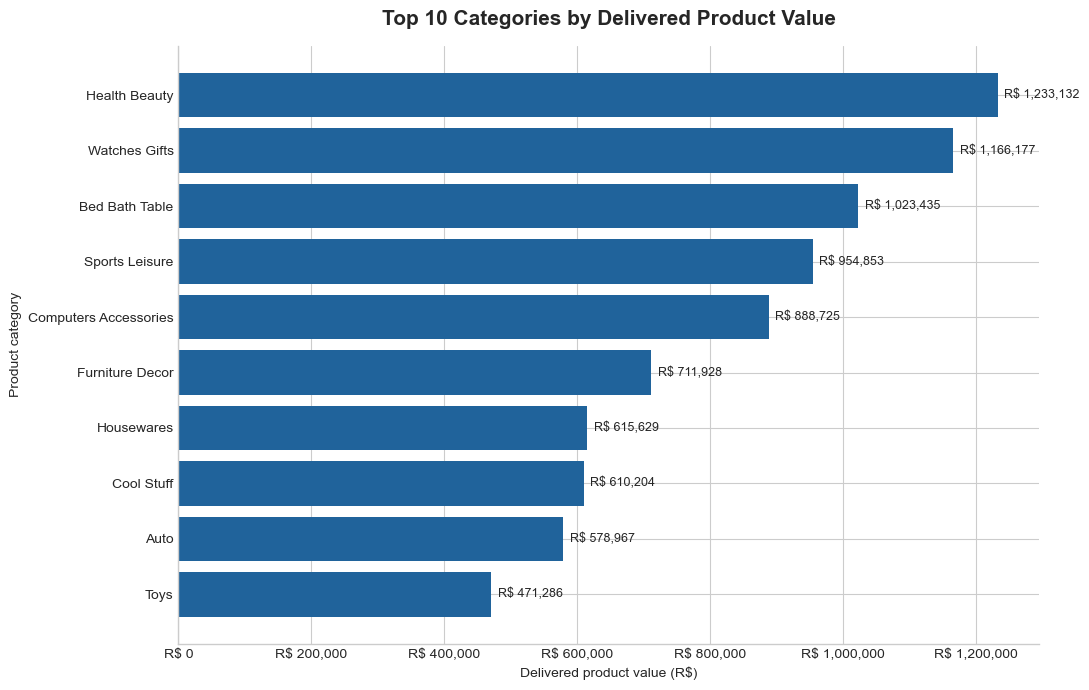

In [14]:
chart_data = top_categories.sort_values(
    "product_value",
    ascending=True
).copy()

chart_data["category_label"] = (
    chart_data["product_category_name_english"]
    .str.replace("_", " ")
    .str.title()
)

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    chart_data["category_label"],
    chart_data["product_value"],
    color=COLORS["secondary"]
)

ax.set_title(
    "Top 10 Categories by Delivered Product Value",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Delivered product value (R$)")
ax.set_ylabel("Product category")

ax.xaxis.set_major_formatter(
    mtick.StrMethodFormatter("R$ {x:,.0f}")
)

for bar, value in zip(
    bars,
    chart_data["product_value"]
):
    ax.text(
        bar.get_width() + 10_000,
        bar.get_y() + bar.get_height() / 2,
        f"R$ {value:,.0f}",
        va="center",
        fontsize=9
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    IMAGE_OUTPUT_DIR
    / "top_categories_by_product_value.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** Health and beauty generated the highest delivered product value at R$1.23 million, representing 9.33% of the total. The top ten categories collectively contributed approximately 62.43% of delivered product value.

***Category comparison:*** Bed, bath and table recorded the largest order and item volume among the leading categories, while watches and gifts generated the second-highest product value with fewer orders because its average item price was substantially higher at R$199.04.

***Business interpretation:*** Category performance is driven by different combinations of sales volume and item price. High-value categories should therefore not be evaluated using product value alone; order volume, average price, freight, delivery, and satisfaction must also be considered.

## 6. Payment Behaviour

Payment methods are analysed at the payment-component level. An order using more than one method can appear in multiple categories, so order counts by payment type are not additive.

In [15]:
payments = pd.read_csv(
    PROCESSED_DATA_DIR / "payments_clean.csv",
    dtype={
        "payment_installments": "Int64"
    }
)

print("Payment records loaded:", f"{len(payments):,}")

Payment records loaded: 103,886


In [16]:
payment_method_summary = (
    payments
    .groupby("payment_type", as_index=False)
    .agg(
        payment_records=("order_id", "size"),
        orders_represented=("order_id", "nunique"),
        payment_value=("payment_value", "sum"),
        average_payment_component=("payment_value", "mean"),
        average_installments=("payment_installments", "mean")
    )
    .sort_values(
        "payment_value",
        ascending=False
    )
    .reset_index(drop=True)
)

payment_method_summary["payment_value_share"] = (
    payment_method_summary["payment_value"]
    / payment_method_summary["payment_value"].sum()
)

payment_method_summary.style.format({
    "payment_records": "{:,.0f}",
    "orders_represented": "{:,.0f}",
    "payment_value": "R$ {:,.2f}",
    "average_payment_component": "R$ {:,.2f}",
    "average_installments": "{:.2f}",
    "payment_value_share": "{:.2%}"
})

,payment_type,payment_records,orders_represented,payment_value,average_payment_component,average_installments,payment_value_share
0,credit_card,"76,795","76,505","R$ 12,542,084.19",R$ 163.32,3.51,78.34%
1,boleto,"19,784","19,784","R$ 2,869,361.27",R$ 145.03,1.00,17.92%
2,voucher,"5,775","3,866","R$ 379,436.87",R$ 65.70,1.00,2.37%
3,debit_card,"1,529","1,528","R$ 217,989.79",R$ 142.57,1.00,1.36%
4,unknown,3,3,R$ 0.00,R$ 0.00,1.00,0.00%


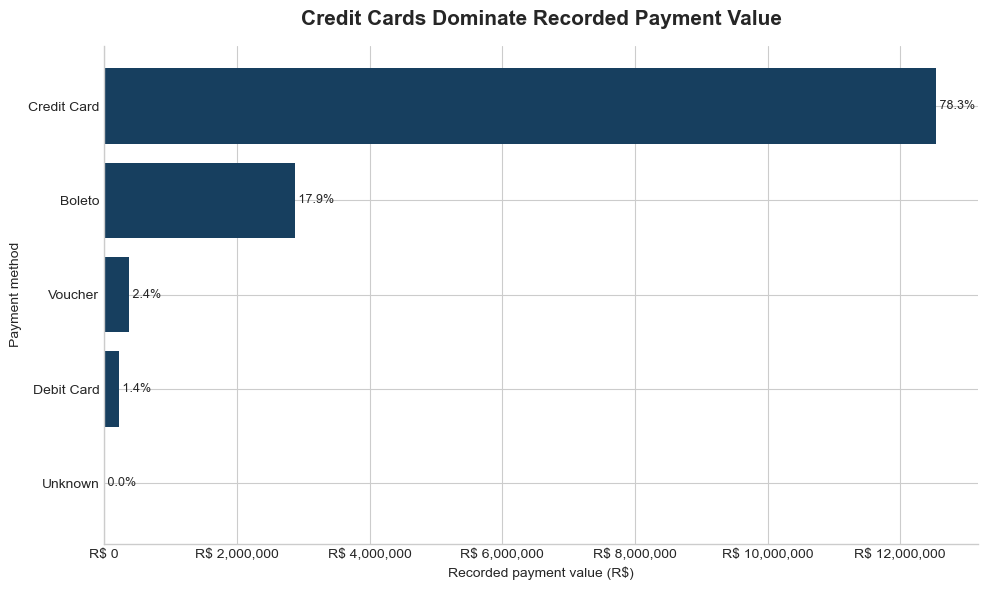

In [17]:
payment_chart_data = (
    payment_method_summary
    .sort_values("payment_value", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    payment_chart_data["payment_type"]
    .str.replace("_", " ")
    .str.title(),
    payment_chart_data["payment_value"],
    color=COLORS["primary"]
)

ax.set_title(
    "Credit Cards Dominate Recorded Payment Value",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Recorded payment value (R$)")
ax.set_ylabel("Payment method")

ax.xaxis.set_major_formatter(
    mtick.StrMethodFormatter("R$ {x:,.0f}")
)

for bar, share in zip(
    bars,
    payment_chart_data["payment_value_share"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {share:.1%}",
        va="center",
        fontsize=9
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    IMAGE_OUTPUT_DIR / "payment_value_by_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** Credit cards account for 78.34% of recorded payment value, followed by boleto at 17.92%. Credit-card payments average 3.51 installments, while the other payment methods are generally recorded as single-installment transactions.

***Payment behaviour:*** Voucher usage appears across 5,775 payment components but only 3,866 orders, indicating that some orders use multiple voucher components or combine vouchers with another payment method.

***Data-quality note:*** The three `unknown` payment records have zero value and make no material contribution to payment totals. Payment-type order counts should not be added together because a single order can use multiple methods.

## 7. Customer Satisfaction Overview

Customer satisfaction is evaluated using the latest recorded review score for each delivered order. Orders without reviews remain excluded from score-based calculations but are not removed from the order dataset.

In [18]:
delivered_reviews = delivered_orders.loc[
    delivered_orders["latest_review_score"].notna()
].copy()

review_score_summary = (
    delivered_reviews["latest_review_score"]
    .astype(int)
    .value_counts()
    .sort_index()
    .rename_axis("review_score")
    .reset_index(name="reviewed_orders")
)

review_score_summary["review_share"] = (
    review_score_summary["reviewed_orders"]
    / review_score_summary["reviewed_orders"].sum()
)

review_score_summary.style.format({
    "reviewed_orders": "{:,.0f}",
    "review_share": "{:.2%}"
})

,review_score,reviewed_orders,review_share
0,1,"9,354",9.76%
1,2,"2,919",3.05%
2,3,"7,916",8.26%
3,4,"18,894",19.72%
4,5,"56,749",59.22%


In [19]:
satisfaction_summary = pd.DataFrame([
    {
        "satisfaction_group": "Low satisfaction (1–2)",
        "reviewed_orders": (
            delivered_reviews["latest_review_score"] <= 2
        ).sum()
    },
    {
        "satisfaction_group": "Neutral (3)",
        "reviewed_orders": (
            delivered_reviews["latest_review_score"] == 3
        ).sum()
    },
    {
        "satisfaction_group": "High satisfaction (4–5)",
        "reviewed_orders": (
            delivered_reviews["latest_review_score"] >= 4
        ).sum()
    }
])

satisfaction_summary["review_share"] = (
    satisfaction_summary["reviewed_orders"]
    / satisfaction_summary["reviewed_orders"].sum()
)

satisfaction_summary.style.format({
    "reviewed_orders": "{:,.0f}",
    "review_share": "{:.2%}"
})

,satisfaction_group,reviewed_orders,review_share
0,Low satisfaction (1–2),"12,273",12.81%
1,Neutral (3),"7,916",8.26%
2,High satisfaction (4–5),"75,643",78.93%


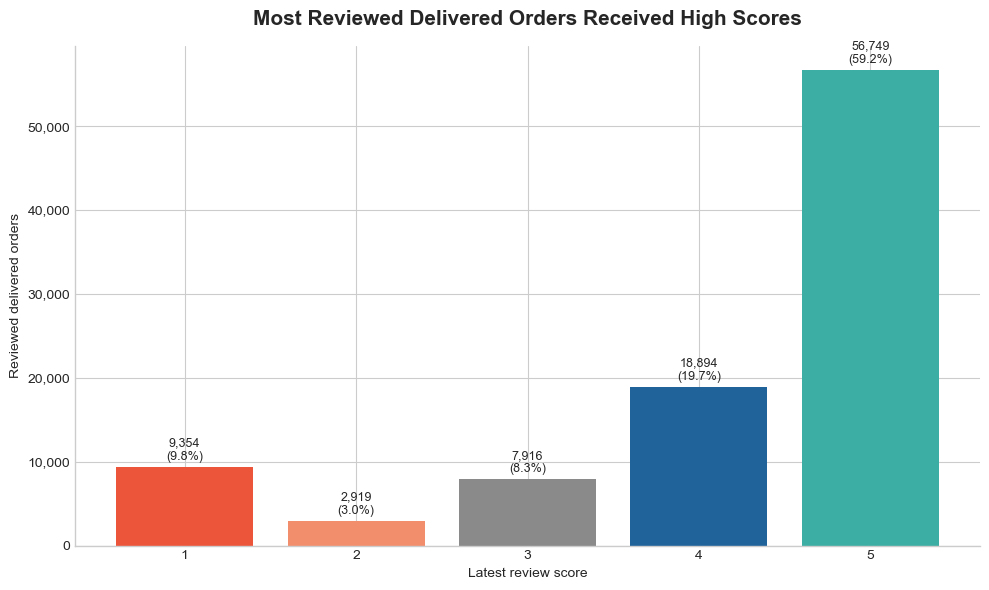

In [20]:
review_colors = [
    COLORS["negative"],
    "#F28E6B",
    COLORS["neutral"],
    COLORS["secondary"],
    COLORS["positive"]
]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    review_score_summary["review_score"],
    review_score_summary["reviewed_orders"],
    color=review_colors
)

ax.set_title(
    "Most Reviewed Delivered Orders Received High Scores",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Latest review score")
ax.set_ylabel("Reviewed delivered orders")

ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter("{x:,.0f}")
)

ax.set_xticks([1, 2, 3, 4, 5])

for bar, count, share in zip(
    bars,
    review_score_summary["reviewed_orders"],
    review_score_summary["review_share"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 800,
        f"{count:,.0f}\n({share:.1%})",
        ha="center",
        fontsize=9
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    IMAGE_OUTPUT_DIR
    / "delivered_order_review_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** High satisfaction scores of 4 or 5 account for 78.93% of reviewed delivered orders, including 59.22% receiving a score of 5. However, 12.81% received a low score of 1 or 2, with one-star reviews alone representing 9.76%.

***Business interpretation:*** Overall satisfaction is favourable, but approximately one in eight reviewed delivered orders received a low score. This group is large enough to justify deeper investigation into delivery delays, sellers, product categories, freight, and other order characteristics.

***Coverage limitation:*** The distribution includes 95,832 delivered orders with recorded reviews. The 646 delivered orders without reviews are excluded, so the results describe reviewed orders rather than every delivered customer experience.

## 8. Delivery and Customer Satisfaction

This section compares review outcomes between on-time and late deliveries. The analysis is limited to delivered orders with valid timestamps and recorded review scores.

In [22]:
delivery_review_analysis = valid_delivery_orders.loc[
    valid_delivery_orders["latest_review_score"].notna()
].copy()

delivery_review_analysis["delivery_status"] = np.where(
    delivery_review_analysis["is_late_delivery"],
    "Late",
    "On time"
)

delivery_review_analysis["is_low_satisfaction"] = (
    delivery_review_analysis["latest_review_score"] <= 2
)

delivery_review_analysis["is_high_satisfaction"] = (
    delivery_review_analysis["latest_review_score"] >= 4
)

In [23]:
delivery_satisfaction_summary = (
    delivery_review_analysis
    .groupby("delivery_status", as_index=False)
    .agg(
        reviewed_orders=("order_id", "nunique"),
        average_review_score=("latest_review_score", "mean"),
        low_satisfaction_rate=("is_low_satisfaction", "mean"),
        high_satisfaction_rate=("is_high_satisfaction", "mean"),
        average_delivery_days=("delivery_days", "mean"),
        average_delay_days=("delivery_delay_days", "mean")
    )
)

delivery_satisfaction_summary.style.format({
    "reviewed_orders": "{:,.0f}",
    "average_review_score": "{:.2f}",
    "low_satisfaction_rate": "{:.2%}",
    "high_satisfaction_rate": "{:.2%}",
    "average_delivery_days": "{:.2f}",
    "average_delay_days": "{:.2f}"
})

,delivery_status,reviewed_orders,average_review_score,low_satisfaction_rate,high_satisfaction_rate,average_delivery_days,average_delay_days
0,Late,"6,378",2.27,62.42%,26.70%,33.82,10.52
1,On time,"89,258",4.29,9.26%,82.66%,11.00,-13.51


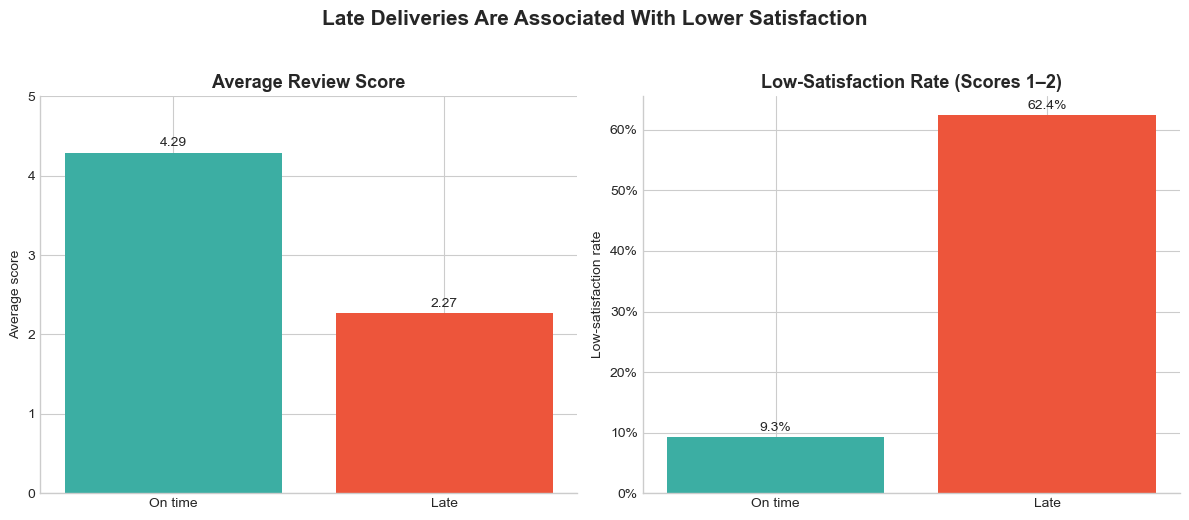

In [24]:
plot_data = (
    delivery_satisfaction_summary
    .set_index("delivery_status")
    .reindex(["On time", "Late"])
    .reset_index()
)

bar_colors = [
    COLORS["positive"],
    COLORS["negative"]
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

bars_1 = axes[0].bar(
    plot_data["delivery_status"],
    plot_data["average_review_score"],
    color=bar_colors
)

axes[0].set_title(
    "Average Review Score",
    fontsize=13,
    fontweight="bold"
)
axes[0].set_ylabel("Average score")
axes[0].set_ylim(0, 5)

for bar, value in zip(
    bars_1,
    plot_data["average_review_score"]
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.08,
        f"{value:.2f}",
        ha="center"
    )

bars_2 = axes[1].bar(
    plot_data["delivery_status"],
    plot_data["low_satisfaction_rate"],
    color=bar_colors
)

axes[1].set_title(
    "Low-Satisfaction Rate (Scores 1–2)",
    fontsize=13,
    fontweight="bold"
)
axes[1].set_ylabel("Low-satisfaction rate")
axes[1].yaxis.set_major_formatter(
    mtick.PercentFormatter(1.0)
)

for bar, value in zip(
    bars_2,
    plot_data["low_satisfaction_rate"]
):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.1%}",
        ha="center"
    )

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Late Deliveries Are Associated With Lower Satisfaction",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()

plt.savefig(
    IMAGE_OUTPUT_DIR
    / "delivery_satisfaction_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** Late deliveries received an average review score of 2.27, compared with 4.29 for on-time deliveries—a difference of 2.02 points. Low-satisfaction scores occurred in 62.42% of late deliveries versus 9.26% of on-time deliveries, making low satisfaction approximately 6.7 times more common among late orders.

***Operational context:*** Late orders took an average of 33.82 days to reach customers and arrived 10.52 days after the estimated date. On-time orders averaged 11.00 delivery days and arrived approximately 13.51 days before their estimated deadline.

***Business interpretation:*** Delivery timeliness is strongly associated with customer satisfaction and should be investigated by seller, category, state, and period. However, this observational comparison does not prove that delays caused every low review because other product, seller, and service factors may also contribute.

***Coverage limitation:*** The comparison includes 95,636 orders with valid delivery timestamps and recorded reviews. Orders without valid timestamps or reviews are excluded.

## 9. Repeat-Purchase Overview

Repeat purchasing is measured using `customer_unique_id`. A repeat customer is someone with more than one observed order during the dataset period. This does not establish future retention or churn.

In [25]:
customer_eda = customer_analytics.copy()

customer_eda["customer_type"] = np.where(
    customer_eda["is_repeat_customer"],
    "Repeat customer",
    "One-time customer"
)

repeat_customer_summary = (
    customer_eda
    .groupby("customer_type", as_index=False)
    .agg(
        customer_count=("customer_unique_id", "nunique"),
        observed_orders=("order_count", "sum"),
        observed_payment_value=("observed_payment_value", "sum"),
        average_orders_per_customer=("order_count", "mean"),
        average_payment_per_customer=(
            "observed_payment_value",
            "mean"
        )
    )
)

repeat_customer_summary["customer_share"] = (
    repeat_customer_summary["customer_count"]
    / repeat_customer_summary["customer_count"].sum()
)

repeat_customer_summary["order_share"] = (
    repeat_customer_summary["observed_orders"]
    / repeat_customer_summary["observed_orders"].sum()
)

repeat_customer_summary["payment_value_share"] = (
    repeat_customer_summary["observed_payment_value"]
    / repeat_customer_summary["observed_payment_value"].sum()
)

repeat_customer_summary.style.format({
    "customer_count": "{:,.0f}",
    "observed_orders": "{:,.0f}",
    "observed_payment_value": "R$ {:,.2f}",
    "average_orders_per_customer": "{:.2f}",
    "average_payment_per_customer": "R$ {:,.2f}",
    "customer_share": "{:.2%}",
    "order_share": "{:.2%}",
    "payment_value_share": "{:.2%}"
})

,customer_type,customer_count,observed_orders,observed_payment_value,average_orders_per_customer,average_payment_per_customer,customer_share,order_share,payment_value_share
0,One-time customer,"93,099","93,099","R$ 15,064,849.41",1.00,R$ 161.82,96.88%,93.62%,94.10%
1,Repeat customer,"2,997","6,342","R$ 944,022.71",2.12,R$ 314.99,3.12%,6.38%,5.90%


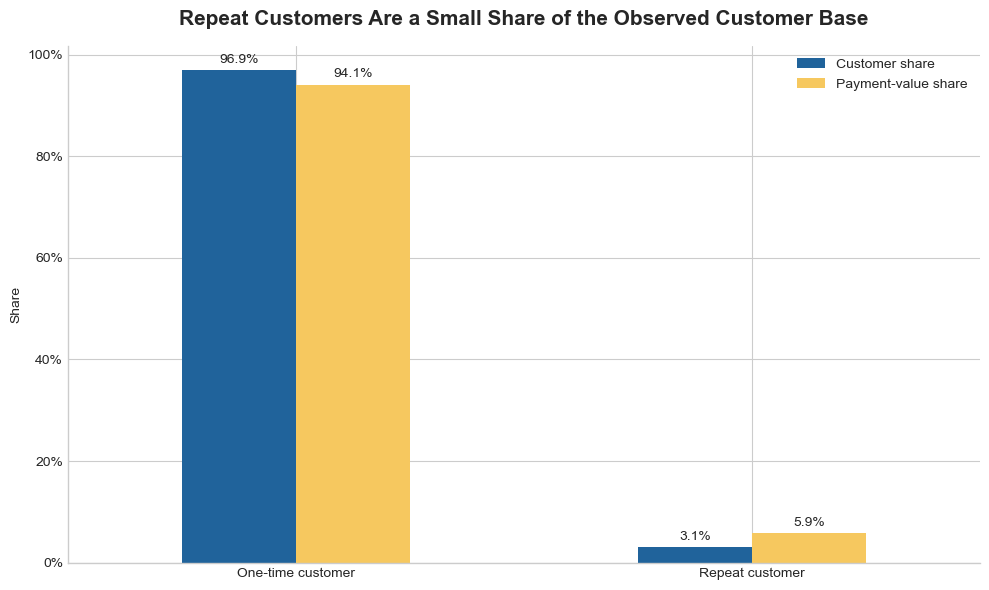

In [26]:
repeat_chart_data = (
    repeat_customer_summary
    .set_index("customer_type")
    .loc[
        ["One-time customer", "Repeat customer"],
        ["customer_share", "payment_value_share"]
    ]
    .rename(
        columns={
            "customer_share": "Customer share",
            "payment_value_share": "Payment-value share"
        }
    )
)

ax = repeat_chart_data.plot(
    kind="bar",
    figsize=(10, 6),
    color=[
        COLORS["secondary"],
        COLORS["accent"]
    ]
)

ax.set_title(
    "Repeat Customers Are a Small Share of the Observed Customer Base",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("")
ax.set_ylabel("Share")
ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(1.0)
)

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{value:.1%}"
            for value in container.datavalues
        ],
        padding=3
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    IMAGE_OUTPUT_DIR
    / "repeat_customer_contribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** One-time customers represent 96.88% of the observed customer base, while only 2,997 customers, or 3.12%, placed more than one order. Repeat customers contributed 6.38% of orders and 5.90% of recorded payment value.

***Customer-value interpretation:*** Repeat customers generated an average of R$314.99 in observed payment value per customer, compared with R$161.82 for one-time customers. This higher customer-level value is primarily explained by their average of 2.12 observed orders rather than proof of greater spending on each individual order.

***Retention limitation:*** The dataset records customer purchases only within a limited historical window. A one-time customer may have purchased again after the dataset ended, so the result measures observed repeat purchasing rather than permanent retention or churn.

## 10. Delivery-Time Distribution

Delivery duration measures the elapsed time from purchase to customer delivery. The analysis uses only orders with complete and chronologically valid timestamps.

In [27]:
delivery_days = (
    valid_delivery_orders["delivery_days"]
    .dropna()
)

delivery_time_summary = pd.DataFrame([
    {
        "statistic": "Valid deliveries",
        "value": delivery_days.count()
    },
    {
        "statistic": "Average delivery days",
        "value": delivery_days.mean()
    },
    {
        "statistic": "Median delivery days",
        "value": delivery_days.median()
    },
    {
        "statistic": "25th percentile",
        "value": delivery_days.quantile(0.25)
    },
    {
        "statistic": "75th percentile",
        "value": delivery_days.quantile(0.75)
    },
    {
        "statistic": "90th percentile",
        "value": delivery_days.quantile(0.90)
    },
    {
        "statistic": "95th percentile",
        "value": delivery_days.quantile(0.95)
    },
    {
        "statistic": "Maximum delivery days",
        "value": delivery_days.max()
    }
])

delivery_time_summary

,statistic,value
0,Valid deliveries,"96,281.00"
1,Average delivery days,12.57
2,Median delivery days,10.23
3,25th percentile,6.78
4,75th percentile,15.73
5,90th percentile,23.11
6,95th percentile,29.29
7,Maximum delivery days,209.63


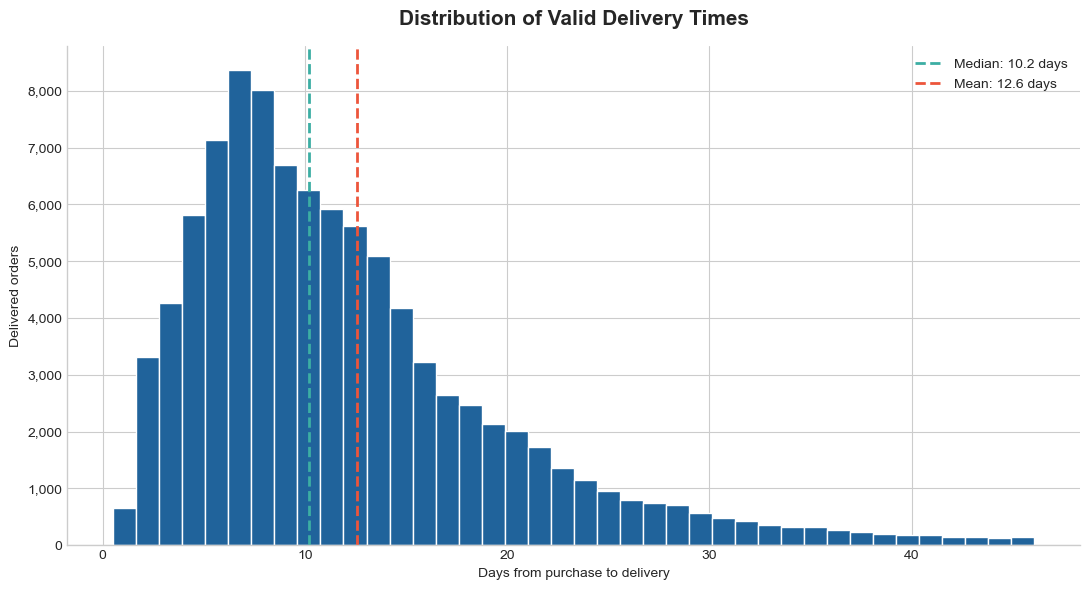

99th-percentile threshold: 46.06 days
Deliveries above the displayed range: 963


In [28]:
delivery_99th_percentile = (
    delivery_days.quantile(0.99)
)

deliveries_above_99th = (
    delivery_days > delivery_99th_percentile
).sum()

fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(
    delivery_days[
        delivery_days <= delivery_99th_percentile
    ],
    bins=40,
    color=COLORS["secondary"],
    edgecolor="white"
)

ax.axvline(
    delivery_days.median(),
    color=COLORS["positive"],
    linestyle="--",
    linewidth=2,
    label=f"Median: {delivery_days.median():.1f} days"
)

ax.axvline(
    delivery_days.mean(),
    color=COLORS["negative"],
    linestyle="--",
    linewidth=2,
    label=f"Mean: {delivery_days.mean():.1f} days"
)

ax.set_title(
    "Distribution of Valid Delivery Times",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Days from purchase to delivery")
ax.set_ylabel("Delivered orders")
ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter("{x:,.0f}")
)

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    IMAGE_OUTPUT_DIR
    / "delivery_time_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "99th-percentile threshold:",
    f"{delivery_99th_percentile:.2f} days"
)

print(
    "Deliveries above the displayed range:",
    f"{deliveries_above_99th:,}"
)

***Observation:*** Valid deliveries took an average of 12.57 days and a median of 10.23 days, indicating that longer delivery cases pull the average upward. Half of deliveries occurred between approximately 6.78 and 15.73 days.

***Operational interpretation:*** Ninety percent of valid deliveries were completed within 23.11 days, while 5% took longer than 29.29 days. The maximum observed duration was 209.63 days, representing an extreme case that should be investigated rather than assumed to describe typical performance.

***Visualisation note:*** The histogram is limited to the 99th percentile for readability. Longer delivery records remain included in the descriptive statistics and underlying data.

## 11. Initial Findings and Business Hypotheses

1. **Marketplace growth:** Delivered order volume and payment value increased substantially between January 2017 and August 2018, while average order payment remained comparatively stable. Growth therefore appears to have been driven mainly by transaction volume.

2. **Seasonal activity:** November 2017 recorded the highest delivered order volume in the comparable period. Seasonal marketplace events may have contributed, but this requires further time-based analysis.

3. **Category concentration:** The ten leading categories generated approximately 62.43% of delivered product value. Health and beauty led by product value, bed, bath and table led by volume, and watches and gifts benefited from a higher average item price.

4. **Payment concentration:** Credit cards represented 78.34% of recorded payment value, while credit cards and boleto together represented 96.26%. Payment behaviour is therefore concentrated in two methods.

5. **Generally strong satisfaction:** Scores of 4 or 5 represented 78.93% of reviewed delivered orders. However, 12.81% received low scores of 1 or 2, creating a meaningful dissatisfied segment.

6. **Delivery-satisfaction relationship:** Low satisfaction occurred in 62.42% of late deliveries compared with 9.26% of on-time deliveries. Late delivery is strongly associated with poor reviews, although the relationship does not prove causation.

7. **Limited observed repeat purchasing:** Only 3.12% of unique customers placed multiple observed orders. This limits strong claims about long-term retention, churn, or predictive customer lifetime value.

8. **Long delivery tail:** Median delivery time was 10.23 days, but 5% of valid deliveries took longer than 29.29 days. These long-duration cases should be investigated by seller, state, and category.

In [29]:
expected_chart_files = [
    "order_status_distribution.png",
    "monthly_order_payment_trends.png",
    "top_categories_by_product_value.png",
    "payment_value_by_method.png",
    "delivered_order_review_distribution.png",
    "delivery_satisfaction_comparison.png",
    "repeat_customer_contribution.png",
    "delivery_time_distribution.png"
]

chart_export_validation = pd.DataFrame({
    "chart_file": expected_chart_files,
    "file_created": [
        (IMAGE_OUTPUT_DIR / filename).exists()
        for filename in expected_chart_files
    ]
})

chart_export_validation

,chart_file,file_created
0,order_status_distribution.png,True
1,monthly_order_payment_trends.png,True
2,top_categories_by_product_value.png,True
3,payment_value_by_method.png,True
4,delivered_order_review_distribution.png,True
5,delivery_satisfaction_comparison.png,True
6,repeat_customer_contribution.png,True
7,delivery_time_distribution.png,True


In [30]:
print(
    "Charts exported:",
    chart_export_validation["file_created"].sum()
)

print(
    "All expected charts created:",
    chart_export_validation["file_created"].all()
)

Charts exported: 8
All expected charts created: True


## Conclusion

***Overall result:*** The exploratory analysis established Olist’s historical business baseline across orders, product value, payment behaviour, categories, satisfaction, delivery, and repeat purchasing.

***Primary finding:*** Late delivery is the strongest initial operational concern. Reviewed late orders had substantially lower average scores and a much higher low-satisfaction rate than reviewed on-time orders.

***Analytical boundaries:*** The results describe historical associations within the available dataset. They do not establish causation, permanent churn, predictive CLV, guaranteed business impact, or future marketplace performance.

***Next step:*** `05_geographic_analysis.ipynb` will investigate how customers, product value, satisfaction, and delivery performance vary across Brazilian states. Brazilian state GeoJSON boundaries will be introduced during that stage.